In [ ]:
import os
import json
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix,accuracy_score, precision_score, 
                             recall_score, f1_score)
from sklearn.model_selection import GroupShuffleSplit

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
DATA_PATH = os.path.join(PROJECT_ROOT,  "Crop_Dataset.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Data", "artifacts")
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# Recreate the test set exactly as before
ENV_COLS = ['temperature','rainfall','sunshine_hours','ph','organic_carbon',
            'cec','awc','bulk_density','texture_code']
rounded = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded, index=False).astype('int64')

y = df['suitability_class'].map({'Suitable':1, 'Unsuitable':0}).astype(int)
DROP_COLS = ['suitability_class','suitability','texture','rooting_depth_m']
X = df.drop(columns=DROP_COLS)
groups = df['scenario_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print("Test set shape:", X_test.shape)

Test set shape: (420, 11)


In [3]:
models = {
    'Random Forest': joblib.load('tuned_rf.pkl'),
    'SVM': joblib.load('tuned_svm.pkl'),
    'Logistic Regression': joblib.load('tuned_logreg.pkl'),
    'XGBoost': joblib.load('tuned_xgb.pkl')
}

print("Models loaded successfully !")

Models loaded successfully !


In [ ]:
# Compute Predictions and Metrics
results = []

for i, (name, model) in enumerate(models.items()):
    # Predict probabilities
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    # Metrics
    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / len(y_test)
    sens = tp / (tp + fn) if (tp+fn)>0 else 0
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    rec = sens
    f1 = 2 * (prec * rec) / (prec + rec) if (prec+rec)>0 else 0


    results.append({
        'Model': name,
        'ROC‑AUC': round(roc, 4),
        'PR‑AUC': round(pr, 4),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1‑Score': round(f1, 4),
        'Sensitivity': round(sens, 4),
        'Specificity': round(spec, 4)
    })


comparison_df = pd.DataFrame(results).sort_values('ROC‑AUC', ascending=False)
print("\n\t\t\t\t---- MODEL COMPARISON ----\n")
print(comparison_df.to_string(index=False))


				---- MODEL COMPARISON ----

              Model  ROC‑AUC  PR‑AUC  Accuracy  Precision  Recall  F1‑Score  Sensitivity  Specificity
                SVM   0.9443  0.9639    0.8667     0.8800  0.8943    0.8871       0.8943       0.8276
            XGBoost   0.9393  0.9593    0.8524     0.8740  0.8740    0.8740       0.8740       0.8218
      Random Forest   0.9297  0.9554    0.8381     0.8504  0.8780    0.8640       0.8780       0.7816
Logistic Regression   0.9138  0.9429    0.8286     0.8425  0.8699    0.8560       0.8699       0.7701


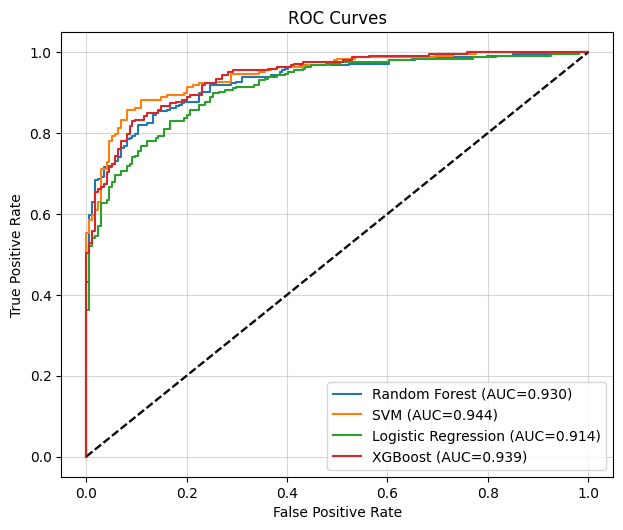

In [6]:
plt.figure(figsize=(12, 10))
for i, (name, model) in enumerate(models.items()):
    # Predict probabilities
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    # Metrics
    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / len(y_test)
    sens = tp / (tp + fn) if (tp+fn)>0 else 0
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    rec = sens
    f1 = 2 * (prec * rec) / (prec + rec) if (prec+rec)>0 else 0


    results.append({
        'Model': name,
        'ROC‑AUC': round(roc, 4),
        'PR‑AUC': round(pr, 4),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1‑Score': round(f1, 4),
        'Sensitivity': round(sens, 4),
        'Specificity': round(spec, 4)
    })
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.subplot(2, 2, 1)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc:.3f})')
    plt.plot([0,1],[0,1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

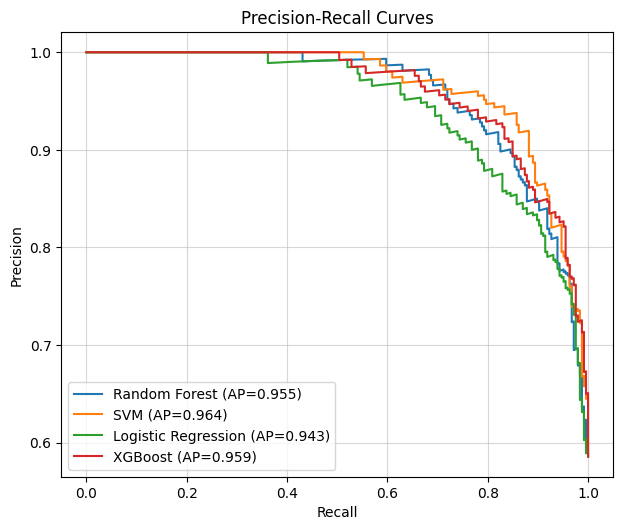

In [7]:
# PR curve
plt.figure(figsize=(12, 10))
for i, (name, model) in enumerate(models.items()):
    # Predict probabilities
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    # Metrics
    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / len(y_test)
    sens = tp / (tp + fn) if (tp+fn)>0 else 0
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    rec = sens
    f1 = 2 * (prec * rec) / (prec + rec) if (prec+rec)>0 else 0


    results.append({
        'Model': name,
        'ROC‑AUC': round(roc, 4),
        'PR‑AUC': round(pr, 4),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1‑Score': round(f1, 4),
        'Sensitivity': round(sens, 4),
        'Specificity': round(spec, 4)
    })

    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.subplot(2, 2, 2)
    plt.plot(rec, prec, label=f'{name} (AP={pr:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision‑Recall Curves')
    plt.legend()
    plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
best_roc = comparison_df.iloc[0]['Model']
best_pr = comparison_df.sort_values('PR‑AUC', ascending=False).iloc[0]['Model']

print(f"Best model by ROC‑AUC:  {best_roc}")
print(f"Best model by PR‑AUC:   {best_pr}")

best_model_name = best_roc
best_model = models[best_model_name]

print(f"\nSelected final model: {best_model_name}")


joblib.dump(best_model, os.path.join(OUTPUT_DIR, 'best_ranking_model.joblib'))
print(f"\n\nModel saved to: {os.path.join(OUTPUT_DIR, 'best_ranking_model.joblib')}")

crop_list = sorted(X['crop'].unique().tolist())
meta = {
    'crop_list': crop_list,
    'threshold_default': 0.5,
    'fallback_sunshine_median': df['sunshine_hours'].median()
}
with open(os.path.join(OUTPUT_DIR, 'training_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print("Metadata saved.")

Best model by ROC‑AUC:  SVM
Best model by PR‑AUC:   SVM

Selected final model: SVM


Model saved to: c:\Users\manur\OneDrive\Desktop\DSGP\Weather-Prediction-and-Crop-Recommendation-System-\Data\artifacts\best_ranking_model.joblib
Metadata saved.
